In [1]:
import sys
sys.path.append("../..")
import numpy as np
import matplotlib.pyplot as plt 
from dipole import log_energy_cross_section
import math

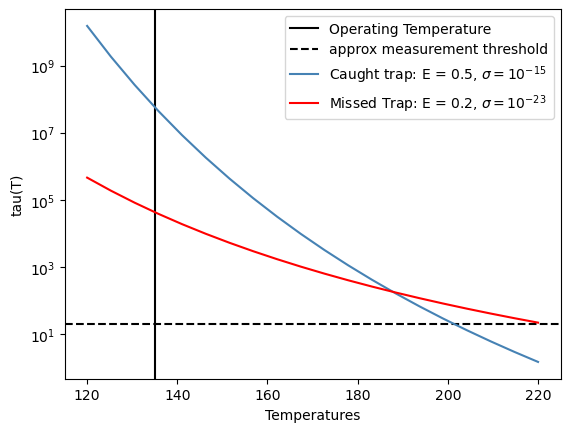

In [8]:
temperatures = np.linspace(120,220,20)

sigma1 = 1e-15
sigma2 = 1e-23
e1 = 0.5
e2 = 0.2
def fmt_sigma_latex(value):
    exp = int(math.floor(math.log10(abs(value))))
    mantissa = value / 10**exp
    if abs(mantissa - 1.0) < 1e-9:
        return rf"$\sigma = 10^{{{exp}}}$"
    return rf"$\sigma = {mantissa:.2g} \times 10^{{{exp}}}$"



logtau  = log_energy_cross_section(temperatures=temperatures,E = e1,logsigma=np.log(sigma1))
logtau2  = log_energy_cross_section(temperatures=temperatures,E = e2,logsigma=np.log(sigma2))
tau = np.exp(logtau)

tau2 = np.exp(logtau2)
plt.axvline(135,color='black',label='Operating Temperature')
plt.axhline(20,label='approx measurement threshold',ls='--',color='black')
plt.plot(temperatures,tau,label=f'Caught trap: E = {e1}, {fmt_sigma_latex(sigma1)}',color='steelblue')
plt.plot(temperatures,tau2,label=f'Missed Trap: E = {e2}, {fmt_sigma_latex(sigma2)}',color='red')
plt.xlabel("Temperatures")
plt.ylabel("tau(T)")
plt.legend()
plt.yscale('log')
plt.show()
plt.close()